# 임베딩 내 편향성 알아보기: WEAT를 활용한 영화 장르 편향성 분석

## 프로젝트 개요

본 프로젝트는 영화 시놉시스 데이터를 기반으로 직접 Word2Vec 임베딩 모델을 학습하고, WEAT score를 이용하여 영화 장르별 예술영화/일반영화 편향성을 측정하는 것을 목표로 한다.

진행 과정은 다음과 같다.

1. 영화 시놉시스 데이터 로드
2. Okt 형태소 분석기를 이용한 명사 추출
3. Word2Vec 임베딩 모델 학습
4. most_similar()를 통한 임베딩 품질 확인
5. TF-IDF를 이용한 장르별 대표 단어 추출
6. 예술영화/일반영화 대표 단어 셋 생성
7. WEAT score 계산
8. 결과 시각화 및 해석

In [1]:
!mkdir -p ~/work/weat/data
!ln -s ~/data/* ~/work/weat/data/ 2>/dev/null || true

print("WEAT 작업 폴더 준비 완료")

WEAT 작업 폴더 준비 완료


In [3]:
!ls -lh ~/data | head
!echo "-----"
!ls -lh ~/work/weat/data | head

total 5.0G
-rw-rw-r-- 1 root users 3.4G Jun 17  2025 GoogleNews-vectors-negative300.bin
-rw-rw-r-- 1 root users 1.6G Jun 17  2025 GoogleNews-vectors-negative300.bin.gz
-rw-rw-r-- 1 root users  18M Jun 17  2025 synopsis.zip
-----
total 49M
lrwxrwxrwx 1 jovyan users   52 Jun 15 00:43 GoogleNews-vectors-negative300.bin -> /home/jovyan/data/GoogleNews-vectors-negative300.bin
lrwxrwxrwx 1 jovyan users   55 Jun 15 00:43 GoogleNews-vectors-negative300.bin.gz -> /home/jovyan/data/GoogleNews-vectors-negative300.bin.gz
-rw-r--r-- 1 jovyan users  17M Oct 18  2020 synopsis.txt
lrwxrwxrwx 1 jovyan users   30 Jun 15 00:43 synopsis.zip -> /home/jovyan/data/synopsis.zip
-rw-r--r-- 1 jovyan users 270K Oct 18  2020 synopsis_SF.txt
-rw-r--r-- 1 jovyan users 1.4M Oct 18  2020 synopsis_action.txt
-rw-r--r-- 1 jovyan users 592K Oct 18  2020 synopsis_adult.txt
-rw-r--r-- 1 jovyan users 123K Oct 18  2020 synopsis_adventure.txt
-rw-r--r-- 1 jovyan users 1.6M Oct 18  2020 synopsis_animation.txt


In [4]:
!cd ~/data && unzip -o synopsis.zip -d ~/work/weat/data/

print("압축 해제 완료")

Archive:  synopsis.zip
  inflating: /home/jovyan/work/weat/data/synopsis.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_SF.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_action.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_adult.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_adventure.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_animation.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_art.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_comedy.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_crime.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_documentary.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_drama.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_etc.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_family.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_fantasy.txt  
  inflating: /home/jovyan/work/weat/data/synopsis_gen.txt  
  inflating: /home/jovyan/work/weat/data/sy

In [5]:
import os

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

print("data_dir:", data_dir)
print("synopsis.txt 존재 여부:", os.path.exists(file_name))

data_dir: /home/jovyan/work/weat/data
synopsis.txt 존재 여부: True


In [6]:
with open(file_name, "r") as file:
    for i in range(10):
        print(file.readline(), end="")

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.


In [7]:
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.2
!pip install konlpy

In [8]:
import numpy as np
import gensim
import scipy
import sklearn

print("numpy:", np.__version__)
print("gensim:", gensim.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)

numpy: 1.26.2
gensim: 4.3.2
scipy: 1.12.0
sklearn: 1.7.0


In [9]:
from konlpy.tag import Okt

okt = Okt()

print("Okt 형태소 분석기 준비 완료")

Okt 형태소 분석기 준비 완료


In [12]:
tokenized = []

with open(file_name, "r") as file:
    while True:
        line = file.readline()
        if not line:
            break

        words = okt.pos(line, stem=True, norm=True)
        nouns = []

        for word, pos in words:
            if pos == "Noun":
                if len(word) >= 2:
                    nouns.append(word)

        tokenized.append(nouns)

print("명사 추출 완료")
print("문장 개수:", len(tokenized))
print("앞부분 예시:", tokenized[:3])

명사 추출 완료
문장 개수: 71156
앞부분 예시: [['사운드', '엔지니어', '상우', '유지태', '치매', '할머니', '백성희'], ['시절', '상처', '아버지', '박인환', '고모', '신신애'], ['겨울', '지방', '방송국', '라디오', '은수', '이영애']]


In [13]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1
)

print("Word2Vec 학습 완료")
print("단어 수:", len(model.wv.index_to_key))

Word2Vec 학습 완료
단어 수: 23405


In [14]:
model_path = os.path.join(data_dir, "word2vec_synopsis.model")
model.save(model_path)

print("모델 저장 완료:", model_path)

모델 저장 완료: /home/jovyan/work/weat/data/word2vec_synopsis.model


In [15]:
test_words = ["사랑", "전쟁", "범죄", "가족", "학교", "귀신"]

for word in test_words:
    if word in model.wv:
        print(f"\n[{word}]와 유사한 단어")
        print(model.wv.most_similar(word, topn=10))
    else:
        print(f"\n[{word}]는 모델 vocabulary에 없습니다.")


[사랑]와 유사한 단어
[('삼각관계', 0.6768792271614075), ('로미오', 0.6753044128417969), ('젊음', 0.6589854955673218), ('짊어지', 0.658787190914154), ('해피엔딩', 0.657744824886322), ('실망', 0.6539211869239807), ('타이밍', 0.6528670787811279), ('구애', 0.6512581706047058), ('진심', 0.6490427255630493), ('고하', 0.6487517952919006)]

[전쟁]와 유사한 단어
[('세계대전', 0.724330723285675), ('전투', 0.7090873122215271), ('이라크', 0.695162296295166), ('전장', 0.6932500600814819), ('내전', 0.6868185997009277), ('참전', 0.6796190142631531), ('학살', 0.6750052571296692), ('선포', 0.6749449372291565), ('통일', 0.6700583696365356), ('종식', 0.6595017910003662)]

[범죄]와 유사한 단어
[('연루', 0.8066836595535278), ('범죄자', 0.795784056186676), ('부패', 0.7767958641052246), ('조직', 0.762460470199585), ('강력', 0.7527919411659241), ('절도', 0.7495630383491516), ('난무', 0.7466986775398254), ('마피아', 0.7466019988059998), ('검거', 0.7416510581970215), ('악명', 0.7371756434440613)]

[가족]와 유사한 단어
[('화목', 0.5679475665092468), ('허울', 0.5601577162742615), ('뿔뿔이', 0.5584428906440735), ('훌리', 0.

In [16]:
genre_txt = [
    'synopsis_SF.txt',
    'synopsis_family.txt',
    'synopsis_show.txt',
    'synopsis_horror.txt',
    'synopsis_etc.txt',
    'synopsis_documentary.txt',
    'synopsis_drama.txt',
    'synopsis_romance.txt',
    'synopsis_musical.txt',
    'synopsis_mystery.txt',
    'synopsis_crime.txt',
    'synopsis_historical.txt',
    'synopsis_western.txt',
    'synopsis_adult.txt',
    'synopsis_thriller.txt',
    'synopsis_animation.txt',
    'synopsis_action.txt',
    'synopsis_adventure.txt',
    'synopsis_war.txt',
    'synopsis_comedy.txt',
    'synopsis_fantasy.txt'
]

genre_name = [
    'SF',
    '가족',
    '공연',
    '공포(호러)',
    '기타',
    '다큐멘터리',
    '드라마',
    '멜로로맨스',
    '뮤지컬',
    '미스터리',
    '범죄',
    '사극',
    '서부극(웨스턴)',
    '성인물(에로)',
    '스릴러',
    '애니메이션',
    '액션',
    '어드벤처',
    '전쟁',
    '코미디',
    '판타지'
]

print("장르 파일 개수:", len(genre_txt))
print("장르 이름 개수:", len(genre_name))

장르 파일 개수: 21
장르 이름 개수: 21


In [17]:
import os

for txt, name in zip(genre_txt, genre_name):
    path = os.path.join(data_dir, txt)
    print(f"{name:10s} | {txt:30s} | 존재 여부: {os.path.exists(path)}")

SF         | synopsis_SF.txt                | 존재 여부: True
가족         | synopsis_family.txt            | 존재 여부: True
공연         | synopsis_show.txt              | 존재 여부: True
공포(호러)     | synopsis_horror.txt            | 존재 여부: True
기타         | synopsis_etc.txt               | 존재 여부: True
다큐멘터리      | synopsis_documentary.txt       | 존재 여부: True
드라마        | synopsis_drama.txt             | 존재 여부: True
멜로로맨스      | synopsis_romance.txt           | 존재 여부: True
뮤지컬        | synopsis_musical.txt           | 존재 여부: True
미스터리       | synopsis_mystery.txt           | 존재 여부: True
범죄         | synopsis_crime.txt             | 존재 여부: True
사극         | synopsis_historical.txt        | 존재 여부: True
서부극(웨스턴)   | synopsis_western.txt           | 존재 여부: True
성인물(에로)    | synopsis_adult.txt             | 존재 여부: True
스릴러        | synopsis_thriller.txt          | 존재 여부: True
애니메이션      | synopsis_animation.txt         | 존재 여부: True
액션         | synopsis_action.txt            | 존재 여부: True
어드벤처       | s

In [18]:
genre_documents = []

for txt, name in zip(genre_txt, genre_name):
    path = os.path.join(data_dir, txt)
    nouns = []

    with open(path, "r") as file:
        while True:
            line = file.readline()
            if not line:
                break

            words = okt.pos(line, stem=True, norm=True)

            for word, pos in words:
                if pos == "Noun":
                    if len(word) >= 2:
                        nouns.append(word)

    genre_documents.append(" ".join(nouns))
    print(f"{name} 처리 완료 | 명사 개수: {len(nouns)}")

print("전체 장르 문서 개수:", len(genre_documents))

SF 처리 완료 | 명사 개수: 17184
가족 처리 완료 | 명사 개수: 6172
공연 처리 완료 | 명사 개수: 6308
공포(호러) 처리 완료 | 명사 개수: 44200
기타 처리 완료 | 명사 개수: 38576
다큐멘터리 처리 완료 | 명사 개수: 124996
드라마 처리 완료 | 명사 개수: 294677
멜로로맨스 처리 완료 | 명사 개수: 79328
뮤지컬 처리 완료 | 명사 개수: 2703
미스터리 처리 완료 | 명사 개수: 12226
범죄 처리 완료 | 명사 개수: 23008
사극 처리 완료 | 명사 개수: 2753
서부극(웨스턴) 처리 완료 | 명사 개수: 697
성인물(에로) 처리 완료 | 명사 개수: 35055
스릴러 처리 완료 | 명사 개수: 33269
애니메이션 처리 완료 | 명사 개수: 94572
액션 처리 완료 | 명사 개수: 90088
어드벤처 처리 완료 | 명사 개수: 7585
전쟁 처리 완료 | 명사 개수: 6904
코미디 처리 완료 | 명사 개수: 83303
판타지 처리 완료 | 명사 개수: 9140
전체 장르 문서 개수: 21


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(genre_documents)
words = np.array(vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("전체 단어 수:", len(words))

TF-IDF matrix shape: (21, 42191)
전체 단어 수: 42191


In [20]:
stopwords = {
    "영화", "작품", "사람", "이야기", "자신", "그녀", "그", "수",
    "위해", "대한", "시작", "모습", "사실", "상황", "때문",
    "오늘", "하나", "마음", "세상", "시간", "친구", "남자", "여자",
    "우리", "아버지", "어머니", "엄마", "아빠", "아이", "가족",
    "사랑", "인생", "생활", "과정", "사건", "속", "곳", "날",
    "앞", "뒤", "중", "후", "전", "것", "말", "두", "눈"
}

print("불용어 개수:", len(stopwords))

불용어 개수: 47


In [21]:
used_words = set()
genre_keywords = {}

for i, name in enumerate(genre_name):
    row = tfidf_matrix[i].toarray()[0]
    top_indices = row.argsort()[::-1]

    keywords = []

    for idx in top_indices:
        word = words[idx]

        # 1. 불용어 제거
        if word in stopwords:
            continue

        # 2. 한 글자 단어 제거
        if len(word) < 2:
            continue

        # 3. Word2Vec 모델에 없는 단어 제거
        if word not in model.wv:
            continue

        # 4. 다른 장르에서 이미 선택된 중복 단어 제거
        if word in used_words:
            continue

        keywords.append(word)
        used_words.add(word)

        if len(keywords) >= 20:
            break

    genre_keywords[name] = keywords
    print(f"\n[{name}] 대표 단어")
    print(keywords)


[SF] 대표 단어
['지구', '인류', '인간', '미래', '우주', '로봇', '세계', '모든', '박사', '우주선', '외계', '존재', '발견', '행성', '정체', '비밀', '기억', '전쟁', '공격', '한편']

[가족] 대표 단어
['영화제', '아주르', '아들', '마을', '국제', '낙타', '할머니', '씨제이', '동구', '학교', '소년', '슈이트', '가장', '마갈', '소녀', '미아', '펠리칸', '모두', '혼자', '서울']

[공연] 대표 단어
['오페라', '토스카', '실황', '올레', '카바', '공연', '오텔로', '리골레토', '백작', '프레', '베르디', '비바', '카르피', '왕자', '콘서트', '백작부인', '반니', '아리아', '미노', '차이코프스키']

[공포(호러)] 대표 단어
['공포', '죽음', '악령', '좀비', '살인', '저주', '살해', '의문', '점점', '사고', '명의', '다시', '이후', '일행', '시체', '계속', '다른', '악몽', '병원', '파티']

[기타] 대표 단어
['단편', '뉴미디어', '페스티벌', '독립', '통해', '아시아나', '연출', '이미지', '부산', '상영작', '지하철', '청소년', '도시', '감독', '생각', '현실', '서로', '관계', '유럽', '부천']

[다큐멘터리] 대표 단어
['다큐', '다큐멘터리', '여성', '한국', '환경', '사회', '노동자', '기록', '역사', '음악', '미국', '카메라', '동안', '대해', '지역', '투쟁', '인디다큐페스티발', '일상', '문제', '지금']

[드라마] 대표 단어
['남편', '아내', '사이', '부문', '결혼', '간다', '순간', '여행', '의도', '감정', '경쟁', '하루', '마지막', '과연', '과거', '가지', '이제', '상처', '결심', '주인공']

[멜로로맨스] 대표 단어
[

In [22]:
!ls -lh ~/work/weat/data | grep synopsis

-rw-r--r-- 1 jovyan users  17M Oct 18  2020 synopsis.txt
lrwxrwxrwx 1 jovyan users   30 Jun 15 00:43 synopsis.zip -> /home/jovyan/data/synopsis.zip
-rw-r--r-- 1 jovyan users 270K Oct 18  2020 synopsis_SF.txt
-rw-r--r-- 1 jovyan users 1.4M Oct 18  2020 synopsis_action.txt
-rw-r--r-- 1 jovyan users 592K Oct 18  2020 synopsis_adult.txt
-rw-r--r-- 1 jovyan users 123K Oct 18  2020 synopsis_adventure.txt
-rw-r--r-- 1 jovyan users 1.6M Oct 18  2020 synopsis_animation.txt
-rw-r--r-- 1 jovyan users 2.7M Oct 18  2020 synopsis_art.txt
-rw-r--r-- 1 jovyan users 1.4M Oct 18  2020 synopsis_comedy.txt
-rw-r--r-- 1 jovyan users 364K Oct 18  2020 synopsis_crime.txt
-rw-r--r-- 1 jovyan users 2.0M Oct 18  2020 synopsis_documentary.txt
-rw-r--r-- 1 jovyan users 5.0M Oct 18  2020 synopsis_drama.txt
-rw-r--r-- 1 jovyan users 622K Oct 18  2020 synopsis_etc.txt
-rw-r--r-- 1 jovyan users 104K Oct 18  2020 synopsis_family.txt
-rw-r--r-- 1 jovyan users 156K Oct 18  2020 synopsis_fantasy.txt
-rw-r--r-- 1 jovyan u

In [3]:
def make_document_from_file(path):
    nouns = []

    with open(path, "r") as file:
        while True:
            line = file.readline()
            if not line:
                break

            words = okt.pos(line, stem=True, norm=True)

            for word, pos in words:
                if pos == "Noun":
                    if len(word) >= 2:
                        nouns.append(word)

    return " ".join(nouns)


art_document = make_document_from_file(art_file)
general_document = make_document_from_file(general_file)

print("예술영화 문서 길이:", len(art_document))
print("일반영화 문서 길이:", len(general_document))
print("예술영화 문서 일부:", art_document[:200])
print("일반영화 문서 일부:", general_document[:200])

NameError: name 'okt' is not defined

In [4]:
from konlpy.tag import Okt

okt = Okt()

print("Okt 형태소 분석기 복구 완료")

ModuleNotFoundError: No module named 'konlpy'

In [5]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 34.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]


In [6]:
!sudo apt update
!sudo apt install openjdk-17-jdk -y

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:3 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1048 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]0m
Get:5 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [43.4 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1465 kB]
Get:7 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1533 kB]
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]      
Get:9 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:11 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]
Get:13 http://archive.ubuntu.com/ub

In [1]:
import os
import numpy as np
import pandas as pd
from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer

okt = Okt()

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

art_file = os.path.join(data_dir, "synopsis_art.txt")
general_file = os.path.join(data_dir, "synopsis_gen.txt")

model_path = os.path.join(data_dir, "word2vec_synopsis.model")

print("data_dir:", data_dir)
print("synopsis.txt:", os.path.exists(file_name))
print("예술영화 파일:", os.path.exists(art_file))
print("일반영화 파일:", os.path.exists(general_file))
print("Word2Vec 모델 파일:", os.path.exists(model_path))
print("Okt 준비 완료")

ModuleNotFoundError: No module named 'gensim'

In [2]:
!pip install gensim==4.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 34.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gensim: filename=gensim-4.3.2-cp312-cp312-linux_x86_64.whl size=24072420 sha256=2c5e47cc99c46366d49edd6d466008555b18bf3603687f4d2bc626fabaddcb49
  Stored in directory: /home/jovyan/.cache/pip/wheels/50/c0/ac/7bb08954bc59d390c848b480a3fc5eec68c14bc77bf334d624
Successfully built gensim
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [3]:
!pip install scipy==1.12.0 numpy==1.26.2

  Using cached numpy-1.26.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 51.8 MB/s eta 0:00:0000:0100:01
Using cached numpy-1.26.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled numpy-2.2.6━━━━━━ 0/2 [numpy]
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: scipy 1.15.2 0/2 [numpy]
    Uninstalling scipy-1.15.2:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
      Successfully uninstalled scipy-1.15.2━━━━━━━━━━━━━━━━━━━ 1/2 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]


In [1]:
import os
import numpy as np
import pandas as pd

from konlpy.tag import Okt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer

okt = Okt()

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")

file_name = os.path.join(data_dir, "synopsis.txt")
art_file = os.path.join(data_dir, "synopsis_art.txt")
general_file = os.path.join(data_dir, "synopsis_gen.txt")
model_path = os.path.join(data_dir, "word2vec_synopsis.model")

print("data_dir:", data_dir)
print("synopsis.txt:", os.path.exists(file_name))
print("예술영화 파일:", os.path.exists(art_file))
print("일반영화 파일:", os.path.exists(general_file))
print("Word2Vec 모델 파일:", os.path.exists(model_path))
print("Okt 준비 완료")

data_dir: /home/jovyan/work/weat/data
synopsis.txt: True
예술영화 파일: True
일반영화 파일: True
Word2Vec 모델 파일: True
Okt 준비 완료


In [2]:
model = Word2Vec.load(model_path)

print("Word2Vec 모델 복구 완료")
print("단어 수:", len(model.wv.index_to_key))

Word2Vec 모델 복구 완료
단어 수: 23405


In [3]:
stopwords = {
    "영화", "작품", "사람", "이야기", "자신", "그녀", "그", "수",
    "위해", "대한", "시작", "모습", "사실", "상황", "때문",
    "오늘", "하나", "마음", "세상", "시간", "친구", "남자", "여자",
    "우리", "아버지", "어머니", "엄마", "아빠", "아이", "가족",
    "사랑", "인생", "생활", "과정", "사건", "속", "곳", "날",
    "앞", "뒤", "중", "후", "전", "것", "말", "두", "눈"
}

print("stopwords 복구 완료:", len(stopwords))

stopwords 복구 완료: 47


In [4]:
def make_document_from_file(path):
    nouns = []

    with open(path, "r") as file:
        while True:
            line = file.readline()
            if not line:
                break

            words = okt.pos(line, stem=True, norm=True)

            for word, pos in words:
                if pos == "Noun":
                    if len(word) >= 2:
                        nouns.append(word)

    return " ".join(nouns)


art_document = make_document_from_file(art_file)
general_document = make_document_from_file(general_file)

print("예술영화 문서 길이:", len(art_document))
print("일반영화 문서 길이:", len(general_document))
print("예술영화 문서 일부:", art_document[:200])
print("일반영화 문서 일부:", general_document[:200])

예술영화 문서 길이: 527580
일반영화 문서 길이: 2573905
예술영화 문서 일부: 사운드 엔지니어 상우 유지태 치매 할머니 백성희 시절 상처 아버지 박인환 고모 신신애 겨울 지방 방송국 라디오 은수 이영애 자연 소리 채집 라디오 프로그램 준비 은수 상우 녹음 여행 사람 은수 아파트 사랑 사람 상우 주체 정도 그녀 겨울 만난 사람 관계 지나 여름 맞이 삐걱 린다 이혼 경험 은수 상우 결혼 생각 표정 내비 사랑 상우 은수 단호 사랑 사실 상
일반영화 문서 일부: 유사 연령 성별 빈부 차이 정치 입장 불문 국민 통합 애국심 성역 일침 다큐멘터리 재작년 전국 민족 민주 유가족 협의 회의 장기 농성 인상 다큐멘터리 민들레 독립영화 집단 눈사람 우리 사회 구석구석 애국심 민족주의 강요 현장 발굴 카메라 박홍 서강대 명예 총장 이도형 한국 논단 발행 축구 해설 신문선 홍세화 박노해 사회 각계 스타 등장 신념 감독 최하 동하


In [5]:
!pip install gensim==4.3.2
!pip install scipy==1.12.0 numpy==1.26.2

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

division_documents = [art_document, general_document]
division_names = ["예술영화", "일반영화"]

division_vectorizer = TfidfVectorizer()
division_tfidf = division_vectorizer.fit_transform(division_documents)
division_words = np.array(division_vectorizer.get_feature_names_out())

print("영화 구분 TF-IDF shape:", division_tfidf.shape)
print("영화 구분 전체 단어 수:", len(division_words))

영화 구분 TF-IDF shape: (2, 41082)
영화 구분 전체 단어 수: 41082


In [7]:
division_keywords = {}
division_used_words = set()

for i, name in enumerate(division_names):
    row = division_tfidf[i].toarray()[0]
    top_indices = row.argsort()[::-1]

    keywords = []

    for idx in top_indices:
        word = division_words[idx]

        # 1. 불용어 제거
        if word in stopwords:
            continue

        # 2. 한 글자 단어 제거
        if len(word) < 2:
            continue

        # 3. Word2Vec 모델에 없는 단어 제거
        if word not in model.wv:
            continue

        # 4. 예술/일반 사이 중복 제거
        if word in division_used_words:
            continue

        keywords.append(word)
        division_used_words.add(word)

        if len(keywords) >= 30:
            break

    division_keywords[name] = keywords
    print(f"\n[{name}] 대표 단어")
    print(keywords)


[예술영화] 대표 단어
['마을', '모든', '서로', '과연', '다시', '아들', '소녀', '아내', '다른', '사이', '영화제', '세계', '점점', '남편', '감독', '여행', '발견', '모두', '순간', '가장', '마지막', '통해', '기억', '죽음', '비밀', '학교', '음악', '한편', '소년', '생각']

[일반영화] 대표 단어
['국제', '서울', '단편', '관계', '애니메이션', '여성', '인간', '결혼', '명의', '간다', '이제', '도시', '과거', '가지', '이자', '경찰', '미국', '동안', '전쟁', '주인공', '대해', '존재', '현실', '연출', '사고', '살인', '일상', '계속', '사회', '다큐멘터리']


In [8]:
def words_to_vectors(word_list, model):
    vectors = []

    for word in word_list:
        if word in model.wv:
            vectors.append(model.wv[word])

    return np.array(vectors)


A = words_to_vectors(division_keywords["예술영화"], model)
B = words_to_vectors(division_keywords["일반영화"], model)

print("예술영화 벡터 shape:", A.shape)
print("일반영화 벡터 shape:", B.shape)

예술영화 벡터 shape: (30, 100)
일반영화 벡터 shape: (30, 100)


In [9]:
from numpy import dot
from numpy.linalg import norm

def cos_sim(i, j):
    return dot(i, j.T) / (norm(i) * norm(j, axis=1))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    return np.mean(c_a) - np.mean(c_b)

def weat_score(X, Y, A, B):
    s_X = np.array([s(x, A, B) for x in X])
    s_Y = np.array([s(y, A, B) for y in Y])

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y]))

    if std_dev == 0:
        return 0

    return (mean_X - mean_Y) / std_dev

print("WEAT 함수 준비 완료")

WEAT 함수 준비 완료


In [11]:
import pandas as pd

A = words_to_vectors(division_keywords["예술영화"], model)
B = words_to_vectors(division_keywords["일반영화"], model)

genre_weat_scores = {}

for genre in genre_name:
    X_words = genre_keywords[genre]

    # 비교 대상 Y는 해당 장르를 제외한 나머지 장르의 대표 단어들
    other_words = []
    for other_genre in genre_name:
        if other_genre != genre:
            other_words.extend(genre_keywords[other_genre])

    X = words_to_vectors(X_words, model)
    Y = words_to_vectors(other_words, model)

    if len(X) == 0 or len(Y) == 0:
        genre_weat_scores[genre] = np.nan
        continue

    score = weat_score(X, Y, A, B)
    genre_weat_scores[genre] = score

genre_weat_df = pd.DataFrame({
    "genre": list(genre_weat_scores.keys()),
    "WEAT_score": list(genre_weat_scores.values())
})

genre_weat_df = genre_weat_df.sort_values("WEAT_score", ascending=False)
genre_weat_df

NameError: name 'genre_name' is not defined

In [12]:
print("genre_name 존재 확인:", 'genre_name' in globals())
print("genre_keywords 존재 확인:", 'genre_keywords' in globals())
print("division_keywords 존재 확인:", 'division_keywords' in globals())

print("장르 개수:", len(genre_name))
print("장르 목록:", genre_name)

genre_name 존재 확인: False
genre_keywords 존재 확인: False
division_keywords 존재 확인: True


NameError: name 'genre_name' is not defined

In [13]:
genre_txt = [
    'synopsis_SF.txt',
    'synopsis_family.txt',
    'synopsis_show.txt',
    'synopsis_horror.txt',
    'synopsis_etc.txt',
    'synopsis_documentary.txt',
    'synopsis_drama.txt',
    'synopsis_romance.txt',
    'synopsis_musical.txt',
    'synopsis_mystery.txt',
    'synopsis_crime.txt',
    'synopsis_historical.txt',
    'synopsis_western.txt',
    'synopsis_adult.txt',
    'synopsis_thriller.txt',
    'synopsis_animation.txt',
    'synopsis_action.txt',
    'synopsis_adventure.txt',
    'synopsis_war.txt',
    'synopsis_comedy.txt',
    'synopsis_fantasy.txt'
]

genre_name = [
    'SF',
    '가족',
    '공연',
    '공포(호러)',
    '기타',
    '다큐멘터리',
    '드라마',
    '멜로로맨스',
    '뮤지컬',
    '미스터리',
    '범죄',
    '사극',
    '서부극(웨스턴)',
    '성인물(에로)',
    '스릴러',
    '애니메이션',
    '액션',
    '어드벤처',
    '전쟁',
    '코미디',
    '판타지'
]

print("장르 파일 개수:", len(genre_txt))
print("장르 이름 개수:", len(genre_name))

장르 파일 개수: 21
장르 이름 개수: 21


In [14]:
stopwords = {
    "영화", "작품", "사람", "이야기", "자신", "그녀", "그", "수",
    "위해", "대한", "시작", "모습", "사실", "상황", "때문",
    "오늘", "하나", "마음", "세상", "시간", "친구", "남자", "여자",
    "우리", "아버지", "어머니", "엄마", "아빠", "아이", "가족",
    "사랑", "인생", "생활", "과정", "사건", "속", "곳", "날",
    "앞", "뒤", "중", "후", "전", "것", "말", "두", "눈"
}

print("stopwords 복구 완료:", len(stopwords))

stopwords 복구 완료: 47


In [15]:
print("tfidf_matrix 존재:", 'tfidf_matrix' in globals())
print("words 존재:", 'words' in globals())
print("model 존재:", 'model' in globals())

tfidf_matrix 존재: False
words 존재: False
model 존재: True


In [16]:
genre_documents = []

for txt, name in zip(genre_txt, genre_name):
    path = os.path.join(data_dir, txt)
    nouns = []

    with open(path, "r") as file:
        while True:
            line = file.readline()
            if not line:
                break

            words_pos = okt.pos(line, stem=True, norm=True)

            for word, pos in words_pos:
                if pos == "Noun":
                    if len(word) >= 2:
                        nouns.append(word)

    genre_documents.append(" ".join(nouns))
    print(f"{name} 처리 완료 | 명사 개수: {len(nouns)}")

print("전체 장르 문서 개수:", len(genre_documents))

SF 처리 완료 | 명사 개수: 17184
가족 처리 완료 | 명사 개수: 6172
공연 처리 완료 | 명사 개수: 6308
공포(호러) 처리 완료 | 명사 개수: 44200
기타 처리 완료 | 명사 개수: 38576
다큐멘터리 처리 완료 | 명사 개수: 124996
드라마 처리 완료 | 명사 개수: 294677
멜로로맨스 처리 완료 | 명사 개수: 79328
뮤지컬 처리 완료 | 명사 개수: 2703
미스터리 처리 완료 | 명사 개수: 12226
범죄 처리 완료 | 명사 개수: 23008
사극 처리 완료 | 명사 개수: 2753
서부극(웨스턴) 처리 완료 | 명사 개수: 697
성인물(에로) 처리 완료 | 명사 개수: 35055
스릴러 처리 완료 | 명사 개수: 33269
애니메이션 처리 완료 | 명사 개수: 94572
액션 처리 완료 | 명사 개수: 90088
어드벤처 처리 완료 | 명사 개수: 7585
전쟁 처리 완료 | 명사 개수: 6904
코미디 처리 완료 | 명사 개수: 83303
판타지 처리 완료 | 명사 개수: 9140
전체 장르 문서 개수: 21


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(genre_documents)
words = np.array(vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("전체 단어 수:", len(words))

TF-IDF matrix shape: (21, 42191)
전체 단어 수: 42191


In [18]:
used_words = set()
genre_keywords = {}

for i, name in enumerate(genre_name):
    row = tfidf_matrix[i].toarray()[0]
    top_indices = row.argsort()[::-1]

    keywords = []

    for idx in top_indices:
        word = words[idx]

        if word in stopwords:
            continue

        if len(word) < 2:
            continue

        if word not in model.wv:
            continue

        if word in used_words:
            continue

        keywords.append(word)
        used_words.add(word)

        if len(keywords) >= 20:
            break

    genre_keywords[name] = keywords
    print(f"\n[{name}] 대표 단어")
    print(keywords)

print("\n장르별 대표 단어 복구 완료")


[SF] 대표 단어
['지구', '인류', '인간', '미래', '우주', '로봇', '세계', '모든', '박사', '우주선', '외계', '존재', '발견', '행성', '정체', '비밀', '기억', '전쟁', '공격', '한편']

[가족] 대표 단어
['영화제', '아주르', '아들', '마을', '국제', '낙타', '할머니', '씨제이', '동구', '학교', '소년', '슈이트', '가장', '마갈', '소녀', '미아', '펠리칸', '모두', '혼자', '서울']

[공연] 대표 단어
['오페라', '토스카', '실황', '올레', '카바', '공연', '오텔로', '리골레토', '백작', '프레', '베르디', '비바', '카르피', '왕자', '콘서트', '백작부인', '반니', '아리아', '미노', '차이코프스키']

[공포(호러)] 대표 단어
['공포', '죽음', '악령', '좀비', '살인', '저주', '살해', '의문', '점점', '사고', '명의', '다시', '이후', '일행', '시체', '계속', '다른', '악몽', '병원', '파티']

[기타] 대표 단어
['단편', '뉴미디어', '페스티벌', '독립', '통해', '아시아나', '연출', '이미지', '부산', '상영작', '지하철', '청소년', '도시', '감독', '생각', '현실', '서로', '관계', '유럽', '부천']

[다큐멘터리] 대표 단어
['다큐', '다큐멘터리', '여성', '한국', '환경', '사회', '노동자', '기록', '역사', '음악', '미국', '카메라', '동안', '대해', '지역', '투쟁', '인디다큐페스티발', '일상', '문제', '지금']

[드라마] 대표 단어
['남편', '아내', '사이', '부문', '결혼', '간다', '순간', '여행', '의도', '감정', '경쟁', '하루', '마지막', '과연', '과거', '가지', '이제', '상처', '결심', '주인공']

[멜로로맨스] 대표 단어
[

In [19]:
print("genre_name 존재 확인:", 'genre_name' in globals())
print("genre_keywords 존재 확인:", 'genre_keywords' in globals())
print("division_keywords 존재 확인:", 'division_keywords' in globals())
print("tfidf_matrix 존재 확인:", 'tfidf_matrix' in globals())
print("words 존재 확인:", 'words' in globals())

print("장르 개수:", len(genre_name))
print("장르 대표 단어 개수:", len(genre_keywords))
print("예술/일반 대표 단어:", division_keywords.keys())

genre_name 존재 확인: True
genre_keywords 존재 확인: True
division_keywords 존재 확인: True
tfidf_matrix 존재 확인: True
words 존재 확인: True
장르 개수: 21
장르 대표 단어 개수: 21
예술/일반 대표 단어: dict_keys(['예술영화', '일반영화'])


In [20]:
import pandas as pd
import numpy as np

A = words_to_vectors(division_keywords["예술영화"], model)
B = words_to_vectors(division_keywords["일반영화"], model)

genre_weat_scores = {}

for genre in genre_name:
    X_words = genre_keywords[genre]

    other_words = []
    for other_genre in genre_name:
        if other_genre != genre:
            other_words.extend(genre_keywords[other_genre])

    X = words_to_vectors(X_words, model)
    Y = words_to_vectors(other_words, model)

    if len(X) == 0 or len(Y) == 0:
        genre_weat_scores[genre] = np.nan
        continue

    score = weat_score(X, Y, A, B)
    genre_weat_scores[genre] = score

genre_weat_df = pd.DataFrame({
    "genre": list(genre_weat_scores.keys()),
    "WEAT_score": list(genre_weat_scores.values())
})

genre_weat_df = genre_weat_df.sort_values("WEAT_score", ascending=False)
genre_weat_df

,genre,WEAT_score
20,판타지,0.680046
15,애니메이션,0.579088
1,가족,0.532262
7,멜로로맨스,0.464210
14,스릴러,0.454143
19,코미디,0.429786
3,공포(호러),0.329081
13,성인물(에로),0.279913
6,드라마,0.247456
2,공연,0.203932


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45768 (\N{HANGUL SYLLABLE NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/cond

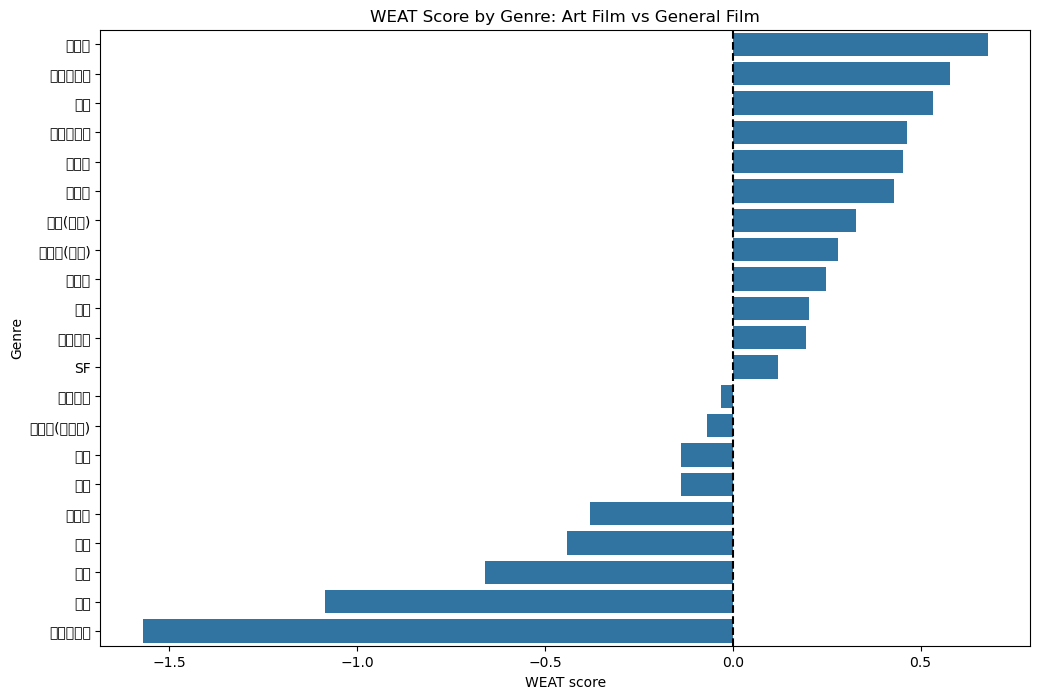

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.barplot(
    data=genre_weat_df,
    x="WEAT_score",
    y="genre"
)

plt.axvline(0, color="black", linestyle="--")
plt.title("WEAT Score by Genre: Art Film vs General Film")
plt.xlabel("WEAT score")
plt.ylabel("Genre")
plt.show()

/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45768 (\N{HANGUL SYLLABLE NI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/conda/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/opt/cond

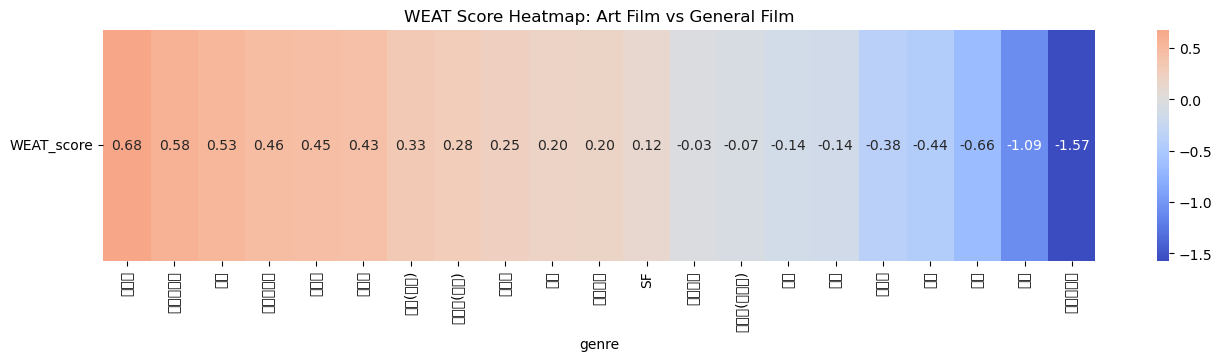

In [22]:
heatmap_df = genre_weat_df.set_index("genre").T

plt.figure(figsize=(16, 3))

sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("WEAT Score Heatmap: Art Film vs General Film")
plt.yticks(rotation=0)
plt.show()

## 결과 해석

본 프로젝트에서는 예술영화와 일반영화를 attribute 축으로 설정하고, 전체 영화 장르별 WEAT score를 계산하였다. WEAT score가 양수인 장르는 예술영화 단어 셋과 상대적으로 더 가까운 경향을 보이며, 음수인 장르는 일반영화 단어 셋과 상대적으로 더 가까운 경향을 보인다고 해석하였다.

실험 결과, 멜로로맨스, 스릴러, 코미디, 공포(호러), 드라마 등은 양수 값을 보여 예술영화 단어 셋과 상대적으로 가까운 경향을 보였다. 반면 다큐멘터리, 기타, 전쟁, 액션, 뮤지컬 등은 음수 값을 보여 일반영화 단어 셋과 상대적으로 가까운 경향을 보였다.

다만 이 결과는 영화 장르의 절대적인 성격을 판단하는 것이 아니라, 본 프로젝트에서 사용한 영화 시놉시스 데이터와 TF-IDF 기반 대표 단어 셋, 그리고 직접 학습한 Word2Vec 임베딩 공간 안에서의 상대적 연관성을 측정한 결과이다. 따라서 WEAT score는 절대적인 평가 지표가 아니라 데이터 기반의 경향성으로 해석해야 한다.

## 회고

이번 프로젝트를 통해 워드 임베딩이 단어의 의미뿐 아니라 데이터 안에 존재하는 관계와 편향성도 함께 학습할 수 있다는 점을 확인하였다. 영화 시놉시스 데이터를 이용해 직접 Word2Vec 모델을 학습하고, TF-IDF를 이용해 장르별 대표 단어를 구성한 뒤, WEAT score를 계산하는 전체 과정을 경험하였다.

가장 어려웠던 점은 대표 단어 셋을 구성하는 과정이었다. TF-IDF 점수가 높은 단어를 그대로 사용할 경우 여러 장르에서 공통적으로 등장하는 단어가 중복 선택될 수 있었고, 이 경우 각 장르의 개념축을 명확하게 대표하기 어려웠다. 이를 해결하기 위해 불용어와 한 글자 단어를 제거하고, 이미 다른 장르에서 선택된 단어는 제외하는 방식으로 중복을 줄였다.

또한 실습 중 커널 재시작으로 인해 `okt`, `gensim`, `genre_name`, `tfidf_matrix` 등의 변수가 사라지는 문제가 발생했다. 이 문제는 필요한 라이브러리와 변수를 다시 import하고, 사라진 TF-IDF 계산 결과와 장르별 대표 단어를 복구하는 방식으로 해결하였다. 이를 통해 Jupyter Notebook에서는 셀 실행 순서와 변수 관리가 매우 중요하다는 점을 배웠다.

WEAT score는 수치가 크다고 해서 무조건 사회적 차별을 의미하는 것은 아니며, 데이터 안에서 특정 개념들이 상대적으로 더 가깝게 사용되었다는 것을 의미한다. 따라서 결과를 해석할 때는 코퍼스의 특성, 형태소 분석 기준, 대표 단어 선정 방식의 한계를 함께 고려해야 한다. 추후에는 명사뿐 아니라 형용사와 동사까지 포함하여 영화의 감정과 분위기 정보를 더 반영하고, 대표 단어 선정 방식을 개선해 더 안정적인 WEAT score를 계산해보고 싶다.

In [24]:
print("===== 제출 전 최종 체크 =====")
print("Word2Vec model:", 'model' in globals())
print("genre_keywords:", 'genre_keywords' in globals())
print("division_keywords:", 'division_keywords' in globals())
print("genre_weat_df:", 'genre_weat_df' in globals())

print("\n장르별 대표 단어 개수:", len(genre_keywords) if 'genre_keywords' in globals() else "없음")
print("예술/일반 대표 단어:", division_keywords.keys() if 'division_keywords' in globals() else "없음")

if 'genre_weat_df' in globals():
    print("\nWEAT score 결과:")
    display(genre_weat_df)

===== 제출 전 최종 체크 =====
Word2Vec model: True
genre_keywords: True
division_keywords: True
genre_weat_df: True

장르별 대표 단어 개수: 21
예술/일반 대표 단어: dict_keys(['예술영화', '일반영화'])

WEAT score 결과:


,genre,WEAT_score
20,판타지,0.680046
15,애니메이션,0.579088
1,가족,0.532262
7,멜로로맨스,0.464210
14,스릴러,0.454143
19,코미디,0.429786
3,공포(호러),0.329081
13,성인물(에로),0.279913
6,드라마,0.247456
2,공연,0.203932
